In [1]:
# Phase 11 – Stage II Reactive Policy | Cell 1: Setup + Load

from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import pickle
import sys

PROJECT = Path(r"D:\univercity\omid_project\economics_project")

OUT_DIR   = PROJECT / "outputs" / "phase11"
OUT_DATA  = OUT_DIR / "data"
OUT_TAB   = OUT_DIR / "tables"
OUT_FIG   = OUT_DIR / "figures"
OUT_MODEL = OUT_DIR / "models"
OUT_LOG   = OUT_DIR / "logs"
for d in [OUT_DATA, OUT_TAB, OUT_FIG, OUT_MODEL, OUT_LOG]:
    d.mkdir(parents=True, exist_ok=True)

P8  = PROJECT / "outputs" / "phase8" / "data"
P10 = PROJECT / "outputs" / "phase10" / "data"

print("=" * 60)
print("Phase 11 – Stage II Reactive Policy | Cell 1")
print("=" * 60)
print(f"Timestamp : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Outputs   : {OUT_DIR}")
print("Embedding : GraphSAGE only (Phase-7 winner)")
print("Policy    : ALL algorithms equal; winner by final benchmark")

# Core arrays
base_features = np.load(P8 / "base_features.npy")
emb = np.load(P8 / "emb_GraphSAGE.npy")
sr_vector = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

if str(P8) not in sys.path:
    sys.path.insert(0, str(P8))
if str(P10) not in sys.path:
    sys.path.insert(0, str(P10))

from economics_env import EconomicsNetworkEnv
# shock_env imports economics_env from path
from shock_env import ShockEconomicsEnv, SHOCK_SERIES, SEVERITY

print(f"base_features : {base_features.shape}")
print(f"emb_GraphSAGE : {emb.shape}")
print(f"nodes         : {len(nodes)}")
print(f"shock series  : {list(SHOCK_SERIES.keys())}")
print(f"severities    : {list(SEVERITY.keys())}")
print(f"agents (project): Government | CentralBank | BankingSector")
print(f"algos (equal)   : MAPPO, MADDPG, QMIX, IPPO, PPO, A2C, A3C, REINFORCE")

print("\nCell 1 completed successfully.")

Phase 11 – Stage II Reactive Policy | Cell 1
Timestamp : 2026-09-30 19:34:32
Outputs   : D:\univercity\omid_project\economics_project\outputs\phase11
Embedding : GraphSAGE only (Phase-7 winner)
Policy    : ALL algorithms equal; winner by final benchmark
base_features : (378, 16)
emb_GraphSAGE : (378, 32)
nodes         : 18
shock series  : ['standard', 'strong']
severities    : ['Mild', 'Moderate', 'Severe', 'Extreme']
agents (project): Government | CentralBank | BankingSector
algos (equal)   : MAPPO, MADDPG, QMIX, IPPO, PPO, A2C, A3C, REINFORCE

Cell 1 completed successfully.


In [2]:
# Phase 11 – Cell 2: Multi-agent shock environment

from pathlib import Path
import sys
import textwrap
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
P8  = PROJECT / "outputs" / "phase8" / "data"
P10 = PROJECT / "outputs" / "phase10" / "data"
OUT_DATA = PROJECT / "outputs" / "phase11" / "data"
OUT_TAB  = PROJECT / "outputs" / "phase11" / "tables"

for p in [str(P8), str(P10)]:
    if p not in sys.path:
        sys.path.insert(0, p)

print("=" * 60)
print("Phase 11 – Cell 2: Multi-agent shock env")
print("=" * 60)

# Persist multi-agent env module
src = textwrap.dedent(r'''
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from shock_env import ShockEconomicsEnv, SHOCK_SERIES, SEVERITY

AGENTS = ["Government", "CentralBank", "BankingSector"]
# each agent: 2 continuous actions in [-1,1]
# Government:    tax, subsidy
# CentralBank:   interest_rate, QE
# BankingSector: credit_supply, risk_appetite
AGENT_ACTION_DIM = 2
JOINT_DIM = len(AGENTS) * AGENT_ACTION_DIM  # 6

class MultiAgentShockEnv(gym.Env):
    """
    Joint-action multi-agent env on top of ShockEconomicsEnv.
    observation: shared global state (same as phase8/10)
    action: Box(6,) ordered as [Gov_tax, Gov_sub, CB_rate, CB_QE, Bank_credit, Bank_risk]
    Also exposes per-agent action slices for IPPO/MAPPO-style learners.
    """
    metadata = {"render_modes": []}

    def __init__(self, base_features, embeddings, sr_vector, panel_index, nodes,
                 level="moderate", shock_type="BankingCrisis", severity="Moderate",
                 shock_series="standard", seed=None):
        super().__init__()
        self.base = ShockEconomicsEnv(
            base_features, embeddings, sr_vector, panel_index, nodes,
            level=level, shock_type=shock_type, severity=severity,
            shock_series=shock_series, seed=seed,
        )
        self.agents = list(AGENTS)
        self.n_agents = len(self.agents)
        self.agent_action_dim = AGENT_ACTION_DIM
        obs_dim = self.base.observation_space.shape[0]
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32)
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(JOINT_DIM,), dtype=np.float32)
        # for independent learners
        self.per_agent_action_space = {
            a: spaces.Box(low=-1.0, high=1.0, shape=(AGENT_ACTION_DIM,), dtype=np.float32)
            for a in self.agents
        }

    def reset(self, seed=None, options=None):
        obs, info = self.base.reset(seed=seed, options=options)
        info = dict(info)
        info["agents"] = self.agents
        info["shock"] = self.base.last_shock_info
        return obs.astype(np.float32), info

    def _map_joint_to_base_action(self, joint):
        """Map 6D multi-agent joint action -> 4D base env action (tax, subsidy, invest, credit)."""
        joint = np.clip(np.asarray(joint, dtype=np.float32), -1.0, 1.0)
        gov_tax, gov_sub = joint[0], joint[1]
        cb_rate, cb_qe = joint[2], joint[3]
        bank_credit, bank_risk = joint[4], joint[5]
        # aggregate into phase-8 action semantics
        tax = gov_tax
        subsidy = 0.5 * gov_sub + 0.3 * cb_qe
        investment = 0.4 * cb_qe + 0.3 * bank_risk
        credit = 0.5 * bank_credit + 0.2 * cb_rate
        return np.array([tax, subsidy, investment, credit], dtype=np.float32)

    def step(self, action):
        base_action = self._map_joint_to_base_action(action)
        obs, reward, term, trunc, info = self.base.step(base_action)
        info = dict(info)
        info["agents"] = self.agents
        info["joint_action"] = np.asarray(action, dtype=np.float32)
        info["base_action"] = base_action
        info["shock"] = self.base.last_shock_info
        # shared reward (cooperative Stage II); can split later if needed
        return obs.astype(np.float32), float(reward), term, trunc, info

    def get_agent_action(self, joint, agent_name):
        i = self.agents.index(agent_name)
        s = i * self.agent_action_dim
        return np.asarray(joint)[s:s + self.agent_action_dim]
''')

mod_path = OUT_DATA / "multi_agent_shock_env.py"
mod_path.write_text(src, encoding="utf-8")
print(f"Saved → {mod_path}")

if str(OUT_DATA) not in sys.path:
    sys.path.insert(0, str(OUT_DATA))
import importlib
import multi_agent_shock_env
importlib.reload(multi_agent_shock_env)
from multi_agent_shock_env import MultiAgentShockEnv, AGENTS, JOINT_DIM

base_features = np.load(P8 / "base_features.npy")
emb = np.load(P8 / "emb_GraphSAGE.npy")
sr = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

# Smoke test standard + strong
for series in ["standard", "strong"]:
    env = MultiAgentShockEnv(
        base_features, emb, sr, panel, nodes,
        level="moderate", shock_type="BankingCrisis", severity="Moderate",
        shock_series=series, seed=0,
    )
    obs, info = env.reset(seed=0)
    total = 0.0
    for _ in range(5):
        a = env.action_space.sample()
        obs, r, term, trunc, info = env.step(a)
        total += r
    print(f"{series:8s} | obs={obs.shape} | joint_action={env.action_space.shape} | "
          f"agents={AGENTS} | R5={total:.3f} | shock={info.get('shock')}")

meta = {
    "agents": AGENTS,
    "joint_dim": JOINT_DIM,
    "embedding": "GraphSAGE",
    "shock_series": ["standard", "strong"],
    "default_level": "moderate",
}
pd.DataFrame([meta]).to_json(OUT_TAB / "phase11_env_meta.json", orient="records", force_ascii=False)
print("\nCell 2 completed successfully.")

Phase 11 – Cell 2: Multi-agent shock env
Saved → D:\univercity\omid_project\economics_project\outputs\phase11\data\multi_agent_shock_env.py
standard | obs=(69,) | joint_action=(6,) | agents=['Government', 'CentralBank', 'BankingSector'] | R5=-1.309 | shock={'shock_type': 'BankingCrisis', 'severity': 'Moderate', 'series': 'standard', 'delta_sr': -0.14960978269305084}
strong   | obs=(69,) | joint_action=(6,) | agents=['Government', 'CentralBank', 'BankingSector'] | R5=-1.929 | shock={'shock_type': 'BankingCrisis', 'severity': 'Moderate', 'series': 'strong', 'delta_sr': -0.24960978269305084}

Cell 2 completed successfully.


In [3]:
# Phase 11 – Cell 3: Equal train PPO / A2C / REINFORCE / IPPO

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from stable_baselines3 import PPO, A2C
from stable_baselines3.common.vec_env import DummyVecEnv

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
P8  = PROJECT / "outputs" / "phase8" / "data"
P10 = PROJECT / "outputs" / "phase10" / "data"
OUT_DATA = PROJECT / "outputs" / "phase11" / "data"
OUT_MODEL = PROJECT / "outputs" / "phase11" / "models"
OUT_TAB = PROJECT / "outputs" / "phase11" / "tables"

for p in [str(P8), str(P10), str(OUT_DATA)]:
    if p not in sys.path:
        sys.path.insert(0, p)

from multi_agent_shock_env import MultiAgentShockEnv, AGENTS

print("=" * 60)
print("Phase 11 – Cell 3: Equal train (PPO/A2C/REINFORCE/IPPO)")
print("=" * 60)

base_features = np.load(P8 / "base_features.npy")
emb = np.load(P8 / "emb_GraphSAGE.npy")
sr = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

TOTAL_TIMESTEPS = 30000
SEED = 0
N_EVAL = 10
# default training shock curriculum: BankingCrisis Moderate (hard but common)
TRAIN_SHOCK = ("BankingCrisis", "Moderate")
SERIES_LIST = ["standard", "strong"]

def make_env(series, seed=SEED):
    def _thunk():
        return MultiAgentShockEnv(
            base_features, emb, sr, panel, nodes,
            level="moderate",
            shock_type=TRAIN_SHOCK[0], severity=TRAIN_SHOCK[1],
            shock_series=series, seed=seed,
        )
    return _thunk

def evaluate(model_predict_fn, series, n_ep=N_EVAL, seed=999):
    rewards, srs = [], []
    for ep in range(n_ep):
        env = MultiAgentShockEnv(
            base_features, emb, sr, panel, nodes,
            level="moderate", shock_type=TRAIN_SHOCK[0], severity=TRAIN_SHOCK[1],
            shock_series=series, seed=seed + ep,
        )
        obs, _ = env.reset(seed=seed + ep)
        done, tot, info = False, 0.0, {}
        while not done:
            action = model_predict_fn(obs)
            obs, r, term, trunc, info = env.step(action)
            tot += r
            done = term or trunc
        rewards.append(tot)
        srs.append(info.get("sr_improve", np.nan))
    return float(np.mean(rewards)), float(np.std(rewards)), float(np.nanmean(srs))

results = []

# ----- SB3: PPO & A2C (joint 6D) -----
for series in SERIES_LIST:
    for name, Cls in [("PPO", PPO), ("A2C", A2C)]:
        print(f"\n--- {name} | series={series} | steps={TOTAL_TIMESTEPS} ---")
        env = DummyVecEnv([make_env(series)])
        model = Cls("MlpPolicy", env, verbose=0, seed=SEED, learning_rate=3e-4, gamma=0.99)
        model.learn(total_timesteps=TOTAL_TIMESTEPS, progress_bar=False)
        path = OUT_MODEL / f"{name}_{series}.zip"
        model.save(str(path))
        def pred(obs, m=model):
            a, _ = m.predict(obs, deterministic=True)
            return a
        mr, sd, ms = evaluate(pred, series)
        results.append({"algorithm": name, "series": series, "mean_reward": mr,
                        "std_reward": sd, "mean_sr_improve": ms, "timesteps": TOTAL_TIMESTEPS})
        print(f"Eval | R={mr:.3f}±{sd:.3f} | dSR={ms:.3f}")

# ----- REINFORCE (joint) -----
class PolicyNet(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(obs_dim, 128), nn.Tanh(), nn.Linear(128, 128), nn.Tanh())
        self.mean = nn.Linear(128, act_dim)
        self.log_std = nn.Parameter(torch.zeros(act_dim))
    def forward(self, x):
        h = self.net(x)
        return self.mean(h), self.log_std.expand_as(self.mean(h))
    def act(self, obs):
        mu, ls = self.forward(obs)
        std = ls.exp()
        dist = torch.distributions.Normal(mu, std)
        a = dist.rsample()
        logp = dist.log_prob(a).sum(-1)
        return torch.tanh(a), logp

def train_reinforce(series, episodes=None):
    # match ~30000 steps: 30000/40 = 750 episodes
    if episodes is None:
        episodes = TOTAL_TIMESTEPS // 40
    env = make_env(series)()
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.shape[0]
    pi = PolicyNet(obs_dim, act_dim)
    opt = torch.optim.Adam(pi.parameters(), lr=3e-4)
    for ep in range(episodes):
        obs, _ = env.reset(seed=SEED + ep)
        logps, rewards = [], []
        done = False
        while not done:
            o = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
            a, logp = pi.act(o)
            action = a.squeeze(0).detach().numpy()
            obs, r, term, trunc, info = env.step(action)
            logps.append(logp)
            rewards.append(r)
            done = term or trunc
        # normalize returns
        R = 0.0
        rets = []
        for r in reversed(rewards):
            R = r + 0.99 * R
            rets.insert(0, R)
        rets = torch.tensor(rets, dtype=torch.float32)
        rets = (rets - rets.mean()) / (rets.std() + 1e-8)
        loss = 0.0
        for lp, Rt in zip(logps, rets):
            loss = loss - lp * Rt
        opt.zero_grad(); loss.backward(); opt.step()
    torch.save(pi.state_dict(), OUT_MODEL / f"REINFORCE_{series}.pt")
    return pi

for series in SERIES_LIST:
    print(f"\n--- REINFORCE | series={series} ---")
    pi = train_reinforce(series)
    def pred(obs, net=pi):
        with torch.no_grad():
            o = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
            mu, _ = net.forward(o)
            return torch.tanh(mu).squeeze(0).numpy()
    mr, sd, ms = evaluate(pred, series)
    results.append({"algorithm": "REINFORCE", "series": series, "mean_reward": mr,
                    "std_reward": sd, "mean_sr_improve": ms, "timesteps": TOTAL_TIMESTEPS})
    print(f"Eval | R={mr:.3f}±{sd:.3f} | dSR={ms:.3f}")

# ----- IPPO: 3 independent small policies, sum actions -----
class AgentPi(nn.Module):
    def __init__(self, obs_dim, act_dim=2):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(obs_dim, 64), nn.Tanh(), nn.Linear(64, act_dim), nn.Tanh())
    def forward(self, x):
        return self.net(x)

def train_ippo(series, episodes=None):
    if episodes is None:
        episodes = TOTAL_TIMESTEPS // 40
    env = make_env(series)()
    obs_dim = env.observation_space.shape[0]
    agents = [AgentPi(obs_dim) for _ in AGENTS]
    opts = [torch.optim.Adam(a.parameters(), lr=3e-4) for a in agents]
    for ep in range(episodes):
        obs, _ = env.reset(seed=SEED + ep)
        traj = {i: [] for i in range(3)}  # (obs, action, reward)
        done = False
        while not done:
            o = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
            acts = []
            for i, pi in enumerate(agents):
                a = pi(o).squeeze(0)
                acts.append(a)
                traj[i].append((obs.copy(), a.detach().numpy().copy()))
            joint = torch.cat(acts).detach().numpy()
            obs, r, term, trunc, info = env.step(joint)
            for i in range(3):
                # last transition reward
                if len(traj[i]) > 0:
                    obs_i, a_i = traj[i][-1]
                    traj[i][-1] = (obs_i, a_i, r)
            done = term or trunc
        # simple policy gradient per agent
        for i, pi in enumerate(agents):
            if not traj[i]:
                continue
            Rs = [t[2] for t in traj[i]]
            R = 0.0
            rets = []
            for r in reversed(Rs):
                R = r + 0.99 * R
                rets.insert(0, R)
            rets = torch.tensor(rets, dtype=torch.float32)
            rets = (rets - rets.mean()) / (rets.std() + 1e-8)
            loss = 0.0
            for (ob, ac, _), Rt in zip(traj[i], rets):
                pred = pi(torch.tensor(ob, dtype=torch.float32).unsqueeze(0)).squeeze(0)
                loss = loss + ((pred - torch.tensor(ac, dtype=torch.float32)) ** 2).mean() * (-Rt)
            # actually maximize reward via -mse * advantage is weak; use reinforce-style on mean
            opts[i].zero_grad()
            # rebuild proper reinforce
            loss = torch.tensor(0.0, requires_grad=True)
            log_term = 0.0
            for (ob, ac, _), Rt in zip(traj[i], rets):
                pred = pi(torch.tensor(ob, dtype=torch.float32).unsqueeze(0)).squeeze(0)
                # gaussian-ish: -||a-mu||^2 as logprob proxy
                lp = -((pred - torch.tensor(ac, dtype=torch.float32)) ** 2).sum()
                log_term = log_term - lp * Rt
            opts[i].zero_grad()
            log_term.backward()
            opts[i].step()
    for i, pi in enumerate(agents):
        torch.save(pi.state_dict(), OUT_MODEL / f"IPPO_{AGENTS[i]}_{series}.pt")
    return agents

for series in SERIES_LIST:
    print(f"\n--- IPPO | series={series} ---")
    agents = train_ippo(series)
    def pred(obs, ag=agents):
        o = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            parts = [pi(o).squeeze(0).numpy() for pi in ag]
        return np.concatenate(parts, axis=0)
    mr, sd, ms = evaluate(pred, series)
    results.append({"algorithm": "IPPO", "series": series, "mean_reward": mr,
                    "std_reward": sd, "mean_sr_improve": ms, "timesteps": TOTAL_TIMESTEPS})
    print(f"Eval | R={mr:.3f}±{sd:.3f} | dSR={ms:.3f}")

df = pd.DataFrame(results)
df.to_csv(OUT_TAB / "phase11_train_batch1.csv", index=False)
print("\n", df.sort_values(["series", "mean_reward"], ascending=[True, False]).to_string(index=False))
print("\nCell 3 completed successfully.")

Phase 11 – Cell 3: Equal train (PPO/A2C/REINFORCE/IPPO)

--- PPO | series=standard | steps=30000 ---
Eval | R=16.478±0.904 | dSR=0.856

--- A2C | series=standard | steps=30000 ---
Eval | R=23.366±0.704 | dSR=1.157

--- PPO | series=strong | steps=30000 ---
Eval | R=-4.867±4.305 | dSR=0.154

--- A2C | series=strong | steps=30000 ---
Eval | R=12.404±1.366 | dSR=0.960

--- REINFORCE | series=standard ---
Eval | R=-10.422±0.755 | dSR=-0.143

--- REINFORCE | series=strong ---
Eval | R=-16.205±0.416 | dSR=-0.312

--- IPPO | series=standard ---
Eval | R=-9.332±0.858 | dSR=-0.111

--- IPPO | series=strong ---
Eval | R=-15.439±0.540 | dSR=-0.276

 algorithm   series  mean_reward  std_reward  mean_sr_improve  timesteps
      A2C standard    23.366465    0.704122         1.156654      30000
      PPO standard    16.478074    0.904167         0.855828      30000
     IPPO standard    -9.332067    0.857845        -0.111380      30000
REINFORCE standard   -10.421648    0.754751        -0.143461     

In [5]:
# Phase 11 – Cell 4: MAPPO / MADDPG / QMIX / A3C (equal budget)

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import deque
import random

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
P8  = PROJECT / "outputs" / "phase8" / "data"
P10 = PROJECT / "outputs" / "phase10" / "data"
OUT_DATA = PROJECT / "outputs" / "phase11" / "data"
OUT_MODEL = PROJECT / "outputs" / "phase11" / "models"
OUT_TAB = PROJECT / "outputs" / "phase11" / "tables"

for p in [str(P8), str(P10), str(OUT_DATA)]:
    if p not in sys.path:
        sys.path.insert(0, p)

from multi_agent_shock_env import MultiAgentShockEnv, AGENTS, JOINT_DIM

print("=" * 60)
print("Phase 11 – Cell 4: MAPPO / MADDPG / QMIX / A3C")
print("=" * 60)

base_features = np.load(P8 / "base_features.npy")
emb = np.load(P8 / "emb_GraphSAGE.npy")
sr = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

TOTAL_TIMESTEPS = 30000
EPISODES = TOTAL_TIMESTEPS // 40  # 750
SEED = 0
TRAIN_SHOCK = ("BankingCrisis", "Moderate")
SERIES_LIST = ["standard", "strong"]
device = torch.device("cpu")

def make_env(series, seed=SEED):
    return MultiAgentShockEnv(
        base_features, emb, sr, panel, nodes,
        level="moderate", shock_type=TRAIN_SHOCK[0], severity=TRAIN_SHOCK[1],
        shock_series=series, seed=seed,
    )

def evaluate(predict_fn, series, n_ep=10, seed=999):
    rewards, srs = [], []
    for ep in range(n_ep):
        env = make_env(series, seed + ep)
        obs, _ = env.reset(seed=seed + ep)
        done, tot, info = False, 0.0, {}
        while not done:
            action = predict_fn(obs)
            obs, r, term, trunc, info = env.step(np.clip(action, -1, 1).astype(np.float32))
            tot += r
            done = term or trunc
        rewards.append(tot)
        srs.append(info.get("sr_improve", np.nan))
    return float(np.mean(rewards)), float(np.std(rewards)), float(np.nanmean(srs))

results = []

# ---------- MAPPO-style: 3 actors + shared critic (PPO-ish updates) ----------
class Actor(nn.Module):
    def __init__(self, obs_dim, act_dim=2):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(obs_dim, 64), nn.Tanh(), nn.Linear(64, act_dim))
        self.log_std = nn.Parameter(torch.zeros(act_dim))
    def forward(self, x):
        mu = self.net(x)
        return mu, self.log_std.exp().expand_as(mu)
    def act(self, x, deterministic=False):
        mu, std = self.forward(x)
        if deterministic:
            return torch.tanh(mu), None
        dist = torch.distributions.Normal(mu, std)
        z = dist.rsample()
        a = torch.tanh(z)
        logp = dist.log_prob(z).sum(-1) - torch.log(1 - a.pow(2) + 1e-6).sum(-1)
        return a, logp

class Critic(nn.Module):
    def __init__(self, obs_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(obs_dim, 128), nn.Tanh(), nn.Linear(128, 1))
    def forward(self, x):
        return self.net(x).squeeze(-1)

#----- FIXED MAPPO block (replace train_mappo + its loop) -----

def train_mappo(series):
    env = make_env(series)
    obs_dim = env.observation_space.shape[0]
    actors = [Actor(obs_dim).to(device) for _ in AGENTS]
    critic = Critic(obs_dim).to(device)
    opt_a = [torch.optim.Adam(a.parameters(), lr=3e-4) for a in actors]
    opt_c = torch.optim.Adam(critic.parameters(), lr=3e-4)

    for ep in range(EPISODES):
        obs, _ = env.reset(seed=SEED + ep)
        traj_obs, traj_act, traj_rew = [], [], []
        done = False
        while not done:
            o = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                parts = []
                for ac in actors:
                    a, _ = ac.act(o)
                    parts.append(a.squeeze(0).cpu().numpy())
                joint = np.concatenate(parts)
            nobs, r, term, trunc, info = env.step(joint)
            traj_obs.append(obs.copy())
            traj_act.append(joint.copy())
            traj_rew.append(r)
            obs = nobs
            done = term or trunc

        # returns
        R, rets = 0.0, []
        for r in reversed(traj_rew):
            R = r + 0.99 * R
            rets.insert(0, R)
        rets = torch.tensor(rets, dtype=torch.float32, device=device)
        rets = (rets - rets.mean()) / (rets.std() + 1e-8)

        for t, ob in enumerate(traj_obs):
            o = torch.tensor(ob, dtype=torch.float32, device=device).unsqueeze(0)
            v = critic(o)
            adv = (rets[t] - v.detach()).item()

            # critic update
            loss_c = F.mse_loss(v, rets[t].reshape_as(v))
            opt_c.zero_grad()
            loss_c.backward()
            opt_c.step()

            # recompute logp with grad for each actor
            joint = traj_act[t]
            for i, ac in enumerate(actors):
                mu, std = ac.forward(o)
                dist = torch.distributions.Normal(mu, std)
                # inverse tanh of stored action slice
                a_np = joint[i * 2:(i + 1) * 2]
                a = torch.tensor(a_np, dtype=torch.float32, device=device).unsqueeze(0)
                # atanh with clamp
                a_clamped = torch.clamp(a, -0.999, 0.999)
                z = 0.5 * (torch.log1p(a_clamped) - torch.log1p(-a_clamped))
                logp = dist.log_prob(z).sum(-1) - torch.log(1 - a_clamped.pow(2) + 1e-6).sum(-1)
                loss_a = -(logp * adv).mean()
                opt_a[i].zero_grad()
                loss_a.backward()
                opt_a[i].step()

    for i, ac in enumerate(actors):
        torch.save(ac.state_dict(), OUT_MODEL / f"MAPPO_{AGENTS[i]}_{series}.pt")
    torch.save(critic.state_dict(), OUT_MODEL / f"MAPPO_critic_{series}.pt")
    return actors

for series in SERIES_LIST:
    print(f"\n--- MAPPO | {series} ---")
    actors = train_mappo(series)
    def pred(obs, acts=actors):
        o = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            parts = [torch.tanh(a.net(o)).squeeze(0).numpy() for a in acts]
        return np.concatenate(parts)
    mr, sd, ms = evaluate(pred, series)
    results.append({"algorithm": "MAPPO", "series": series, "mean_reward": mr, "std_reward": sd, "mean_sr_improve": ms, "timesteps": TOTAL_TIMESTEPS})
    print(f"Eval | R={mr:.3f}±{sd:.3f} | dSR={ms:.3f}")

# ---------- MADDPG-style: centralized critic, deterministic actors ----------
class DetActor(nn.Module):
    def __init__(self, obs_dim, act_dim=2):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(obs_dim, 64), nn.ReLU(), nn.Linear(64, act_dim), nn.Tanh())
    def forward(self, x):
        return self.net(x)

class CentCritic(nn.Module):
    def __init__(self, obs_dim, joint_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(obs_dim + joint_dim, 128), nn.ReLU(), nn.Linear(128, 1))
    def forward(self, o, a):
        return self.net(torch.cat([o, a], -1)).squeeze(-1)

def train_maddpg(series):
    env = make_env(series)
    obs_dim = env.observation_space.shape[0]
    actors = [DetActor(obs_dim).to(device) for _ in AGENTS]
    critic = CentCritic(obs_dim, JOINT_DIM).to(device)
    opt_a = [torch.optim.Adam(a.parameters(), lr=3e-4) for a in actors]
    opt_c = torch.optim.Adam(critic.parameters(), lr=3e-4)
    buf = deque(maxlen=20000)
    for ep in range(EPISODES):
        obs, _ = env.reset(seed=SEED + ep)
        done = False
        while not done:
            o = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                parts = [ac(o).squeeze(0) for ac in actors]
            joint_t = torch.cat(parts)
            noise = 0.1 * torch.randn_like(joint_t)
            joint = torch.clamp(joint_t + noise, -1, 1).cpu().numpy()
            nobs, r, term, trunc, info = env.step(joint)
            buf.append((obs.copy(), joint.copy(), r, nobs.copy(), float(term or trunc)))
            obs = nobs
            done = term or trunc
            if len(buf) >= 256:
                batch = random.sample(buf, 256)
                o = torch.tensor(np.array([b[0] for b in batch]), dtype=torch.float32, device=device)
                a = torch.tensor(np.array([b[1] for b in batch]), dtype=torch.float32, device=device)
                rr = torch.tensor([b[2] for b in batch], dtype=torch.float32, device=device)
                no = torch.tensor(np.array([b[3] for b in batch]), dtype=torch.float32, device=device)
                dd = torch.tensor([b[4] for b in batch], dtype=torch.float32, device=device)
                with torch.no_grad():
                    na = torch.cat([ac(no) for ac in actors], -1)
                    tq = rr + 0.99 * (1 - dd) * critic(no, na)
                q = critic(o, a)
                loss_c = F.mse_loss(q, tq)
                opt_c.zero_grad(); loss_c.backward(); opt_c.step()
                # actors
                pred_joint = torch.cat([ac(o) for ac in actors], -1)
                loss_a = -critic(o, pred_joint).mean()
                for op in opt_a:
                    op.zero_grad()
                loss_a.backward()
                for op in opt_a:
                    op.step()
    for i, ac in enumerate(actors):
        torch.save(ac.state_dict(), OUT_MODEL / f"MADDPG_{AGENTS[i]}_{series}.pt")
    return actors

for series in SERIES_LIST:
    print(f"\n--- MADDPG | {series} ---")
    actors = train_maddpg(series)
    def pred(obs, acts=actors):
        o = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            return torch.cat([ac(o) for ac in acts], -1).squeeze(0).numpy()
    mr, sd, ms = evaluate(pred, series)
    results.append({"algorithm": "MADDPG", "series": series, "mean_reward": mr, "std_reward": sd, "mean_sr_improve": ms, "timesteps": TOTAL_TIMESTEPS})
    print(f"Eval | R={mr:.3f}±{sd:.3f} | dSR={ms:.3f}")

# ---------- QMIX-approx: discretize joint (coarse) + value mixing ----------
N_BINS = 3  # per agent-dim -> manageable
# Use independent Q over each agent's 2D discretized actions (3^2=9 per agent) - simplified VDN/QMIX-style sum

class AgentQ(nn.Module):
    def __init__(self, obs_dim, n_act=9):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(obs_dim, 64), nn.ReLU(), nn.Linear(64, n_act))
    def forward(self, x):
        return self.net(x)

def idx_to_2d(idx):
    d0, d1 = idx % N_BINS, idx // N_BINS
    return np.array([-1 + 2*d0/(N_BINS-1), -1 + 2*d1/(N_BINS-1)], dtype=np.float32)

def train_qmix(series):
    env = make_env(series)
    obs_dim = env.observation_space.shape[0]
    n_act = N_BINS * N_BINS
    qs = [AgentQ(obs_dim, n_act).to(device) for _ in AGENTS]
    tqs = [AgentQ(obs_dim, n_act).to(device) for _ in AGENTS]
    for i in range(3):
        tqs[i].load_state_dict(qs[i].state_dict())
    opts = [torch.optim.Adam(q.parameters(), lr=1e-3) for q in qs]
    buf = deque(maxlen=20000)
    eps = 1.0
    for ep in range(EPISODES):
        obs, _ = env.reset(seed=SEED + ep)
        done = False
        while not done:
            o = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            acts_idx = []
            parts = []
            for i, q in enumerate(qs):
                if random.random() < eps:
                    idx = random.randrange(n_act)
                else:
                    with torch.no_grad():
                        idx = int(q(o).argmax().item())
                acts_idx.append(idx)
                parts.append(idx_to_2d(idx))
            joint = np.concatenate(parts)
            nobs, r, term, trunc, info = env.step(joint)
            buf.append((obs.copy(), acts_idx, r, nobs.copy(), float(term or trunc)))
            obs = nobs
            done = term or trunc
            if len(buf) >= 256:
                batch = random.sample(buf, 256)
                o = torch.tensor(np.array([b[0] for b in batch]), dtype=torch.float32, device=device)
                no = torch.tensor(np.array([b[3] for b in batch]), dtype=torch.float32, device=device)
                rr = torch.tensor([b[2] for b in batch], dtype=torch.float32, device=device)
                dd = torch.tensor([b[4] for b in batch], dtype=torch.float32, device=device)
                loss = 0.0
                for i, q in enumerate(qs):
                    a_i = torch.tensor([b[1][i] for b in batch], dtype=torch.int64, device=device)
                    qv = q(o).gather(1, a_i.view(-1, 1)).squeeze(1)
                    with torch.no_grad():
                        tv = rr + 0.99 * (1 - dd) * tqs[i](no).max(1)[0]
                    loss = loss + F.mse_loss(qv, tv)
                for op in opts:
                    op.zero_grad()
                loss.backward()
                for op in opts:
                    op.step()
        eps = max(0.05, eps * 0.995)
        if ep % 20 == 0:
            for i in range(3):
                tqs[i].load_state_dict(qs[i].state_dict())
    for i, q in enumerate(qs):
        torch.save(q.state_dict(), OUT_MODEL / f"QMIX_{AGENTS[i]}_{series}.pt")
    return qs

for series in SERIES_LIST:
    print(f"\n--- QMIX-approx | {series} ---")
    qs = train_qmix(series)
    def pred(obs, nets=qs):
        o = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
        parts = []
        with torch.no_grad():
            for q in nets:
                idx = int(q(o).argmax().item())
                parts.append(idx_to_2d(idx))
        return np.concatenate(parts)
    mr, sd, ms = evaluate(pred, series)
    results.append({"algorithm": "QMIX", "series": series, "mean_reward": mr, "std_reward": sd, "mean_sr_improve": ms, "timesteps": TOTAL_TIMESTEPS})
    print(f"Eval | R={mr:.3f}±{sd:.3f} | dSR={ms:.3f}")

# ---------- A3C-style: async-like multiple workers sequential (shared policy) ----------
class A3CNet(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.body = nn.Sequential(nn.Linear(obs_dim, 128), nn.Tanh())
        self.mu = nn.Linear(128, act_dim)
        self.v = nn.Linear(128, 1)
        self.log_std = nn.Parameter(torch.zeros(act_dim))
    def forward(self, x):
        h = self.body(x)
        return self.mu(h), self.log_std.exp().expand(x.size(0), -1), self.v(h).squeeze(-1)

def train_a3c(series, n_workers=4):
    env0 = make_env(series)
    obs_dim = env0.observation_space.shape[0]
    act_dim = env0.action_space.shape[0]
    net = A3CNet(obs_dim, act_dim).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=3e-4)
    eps_each = EPISODES // n_workers
    for w in range(n_workers):
        env = make_env(series, SEED + w * 1000)
        for ep in range(eps_each):
            obs, _ = env.reset(seed=SEED + w * 10000 + ep)
            logps, vals, rewards = [], [], []
            done = False
            while not done:
                o = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
                mu, std, v = net(o)
                dist = torch.distributions.Normal(mu, std)
                z = dist.rsample()
                a = torch.tanh(z)
                logp = dist.log_prob(z).sum(-1) - torch.log(1 - a.pow(2) + 1e-6).sum(-1)
                obs, r, term, trunc, info = env.step(a.squeeze(0).detach().cpu().numpy())
                logps.append(logp.squeeze(0))
                vals.append(v.squeeze(0))
                rewards.append(r)
                done = term or trunc
            R, rets = 0.0, []
            for r in reversed(rewards):
                R = r + 0.99 * R
                rets.insert(0, R)
            rets = torch.tensor(rets, dtype=torch.float32, device=device)
            vals_t = torch.stack(vals)
            adv = rets - vals_t.detach()
            loss = 0.0
            for lp, ad, v, Rt in zip(logps, adv, vals_t, rets):
                loss = loss - lp * ad + 0.5 * (v - Rt).pow(2)
            opt.zero_grad(); loss.backward(); opt.step()
    torch.save(net.state_dict(), OUT_MODEL / f"A3C_{series}.pt")
    return net

for series in SERIES_LIST:
    print(f"\n--- A3C | {series} ---")
    net = train_a3c(series)
    def pred(obs, n=net):
        o = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            mu, _, _ = n(o)
            return torch.tanh(mu).squeeze(0).numpy()
    mr, sd, ms = evaluate(pred, series)
    results.append({"algorithm": "A3C", "series": series, "mean_reward": mr, "std_reward": sd, "mean_sr_improve": ms, "timesteps": TOTAL_TIMESTEPS})
    print(f"Eval | R={mr:.3f}±{sd:.3f} | dSR={ms:.3f}")

df = pd.DataFrame(results)
df.to_csv(OUT_TAB / "phase11_train_batch2.csv", index=False)
print("\n", df.sort_values(["series", "mean_reward"], ascending=[True, False]).to_string(index=False))
print("\nCell 4 completed successfully.")

Phase 11 – Cell 4: MAPPO / MADDPG / QMIX / A3C

--- MAPPO | standard ---
Eval | R=20.620±0.716 | dSR=1.107

--- MAPPO | strong ---
Eval | R=2.962±1.493 | dSR=0.555

--- MADDPG | standard ---
Eval | R=23.365±0.704 | dSR=1.157

--- MADDPG | strong ---
Eval | R=12.404±1.366 | dSR=0.960

--- QMIX-approx | standard ---
Eval | R=15.841±1.391 | dSR=0.875

--- QMIX-approx | strong ---
Eval | R=9.659±2.217 | dSR=0.851

--- A3C | standard ---
Eval | R=10.894±0.768 | dSR=0.797

--- A3C | strong ---
Eval | R=-10.898±1.167 | dSR=0.004

 algorithm   series  mean_reward  std_reward  mean_sr_improve  timesteps
   MADDPG standard    23.365415    0.704262         1.156653      30000
    MAPPO standard    20.619790    0.715650         1.107127      30000
     QMIX standard    15.841253    1.390759         0.875205      30000
      A3C standard    10.894372    0.768402         0.797225      30000
   MADDPG   strong    12.403755    1.365727         0.959999      30000
     QMIX   strong     9.659344    2.2

Phase 11 – Cell 5: Final equal benchmark

=== STANDARD ===
algorithm  mean_reward  std_reward  mean_sr_improve
      A2C    23.366465    0.704122         1.156654
   MADDPG    23.365415    0.704262         1.156653
    MAPPO    20.619790    0.715650         1.107127
      PPO    16.478074    0.904167         0.855828
     QMIX    15.841253    1.390759         0.875205
      A3C    10.894372    0.768402         0.797225
     IPPO    -9.332067    0.857845        -0.111380
REINFORCE   -10.421648    0.754751        -0.143461

=== STRONG ===
algorithm  mean_reward  std_reward  mean_sr_improve
      A2C    12.403755    1.365727         0.959999
   MADDPG    12.403755    1.365727         0.959999
     QMIX     9.659344    2.216661         0.850655
    MAPPO     2.961840    1.492859         0.555290
      PPO    -4.866920    4.304605         0.154208
      A3C   -10.897531    1.167321         0.004099
     IPPO   -15.438840    0.539945        -0.276192
REINFORCE   -16.204862    0.416099       

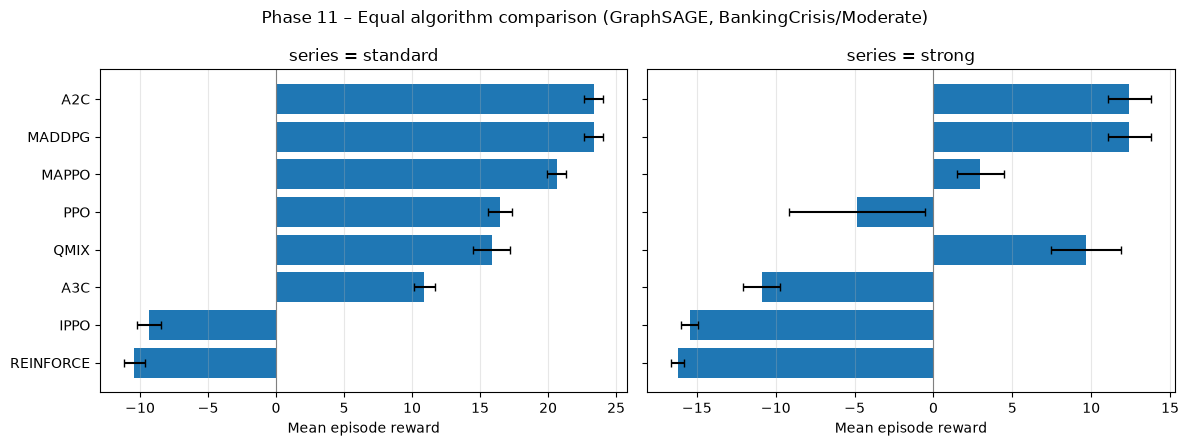


Saved → D:\univercity\omid_project\economics_project\outputs\phase11\tables\phase11_full_benchmark.csv
Saved → D:\univercity\omid_project\economics_project\outputs\phase11\figures\phase11_equal_benchmark.png

Cell 5 completed successfully.
PHASE 11 EVALUATION COMPLETED.


In [6]:
# Phase 11 – Cell 5: Final equal benchmark (all algorithms)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase11" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase11" / "figures"
OUT_DATA = PROJECT / "outputs" / "phase11" / "data"

print("=" * 60)
print("Phase 11 – Cell 5: Final equal benchmark")
print("=" * 60)

b1 = pd.read_csv(OUT_TAB / "phase11_train_batch1.csv")
b2 = pd.read_csv(OUT_TAB / "phase11_train_batch2.csv")
bench = pd.concat([b1, b2], ignore_index=True)

# ensure columns
for c in ["algorithm", "series", "mean_reward", "std_reward", "mean_sr_improve", "timesteps"]:
    if c not in bench.columns:
        raise ValueError(f"missing column: {c}")

bench["embedding"] = "GraphSAGE"
bench["eval_shock"] = "BankingCrisis/Moderate"
bench = bench.sort_values(["series", "mean_reward"], ascending=[True, False]).reset_index(drop=True)
bench.to_csv(OUT_TAB / "phase11_full_benchmark.csv", index=False)

print("\n=== STANDARD ===")
print(bench[bench.series == "standard"][
    ["algorithm", "mean_reward", "std_reward", "mean_sr_improve"]
].to_string(index=False))

print("\n=== STRONG ===")
print(bench[bench.series == "strong"][
    ["algorithm", "mean_reward", "std_reward", "mean_sr_improve"]
].to_string(index=False))

# ranking tables (informational only)
for series in ["standard", "strong"]:
    sub = bench[bench.series == series].copy()
    sub["rank"] = range(1, len(sub) + 1)
    sub.to_csv(OUT_TAB / f"phase11_ranking_{series}.csv", index=False)

# bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, series in zip(axes, ["standard", "strong"]):
    sub = bench[bench.series == series].sort_values("mean_reward")
    ax.barh(sub["algorithm"], sub["mean_reward"], xerr=sub["std_reward"], capsize=3)
    ax.axvline(0, color="gray", lw=0.8)
    ax.set_title(f"series = {series}")
    ax.set_xlabel("Mean episode reward")
    ax.grid(True, axis="x", alpha=0.3)
fig.suptitle("Phase 11 – Equal algorithm comparison (GraphSAGE, BankingCrisis/Moderate)")
plt.tight_layout()
fig.savefig(OUT_FIG / "phase11_equal_benchmark.png", dpi=150)
plt.show()

# summary payload for next phase (no forced winner)
payload = {
    "embedding": "GraphSAGE",
    "algorithms": sorted(bench["algorithm"].unique().tolist()),
    "series": ["standard", "strong"],
    "benchmark_table": str(OUT_TAB / "phase11_full_benchmark.csv"),
    "note": "Equal evaluation only; model for next phase chosen externally",
}
import json
(OUT_DATA / "phase11_benchmark_meta.json").write_text(
    json.dumps(payload, indent=2), encoding="utf-8"
)

print(f"\nSaved → {OUT_TAB / 'phase11_full_benchmark.csv'}")
print(f"Saved → {OUT_FIG / 'phase11_equal_benchmark.png'}")
print("\nCell 5 completed successfully.")
print("PHASE 11 EVALUATION COMPLETED.")